In [1]:
# Four different types of individuals to test:
from individual import QChromosomeRepairPermutationEncoding, QChromosomePositionEncoding, QChromosomeHashPermutationEncoding, QChromosomeHashMultisetEncoding, QChromosomeHashMultisetImprovedEncoding

# Importing libraries
import numpy as np
import pandas as pd
import pdb
from omegaconf import DictConfig
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import seaborn as sns
from typing import List
import math
import decimal
import json
from sympy.combinatorics.graycode import bin_to_gray, gray_to_bin

In [2]:
a = a_previous = 1/np.sqrt(2)
b = b_previous = 1/np.sqrt(2)

In [3]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica"
})

0: 0.024471741852423172
1: 0.975528258147577
sum = 1.0000000000000002


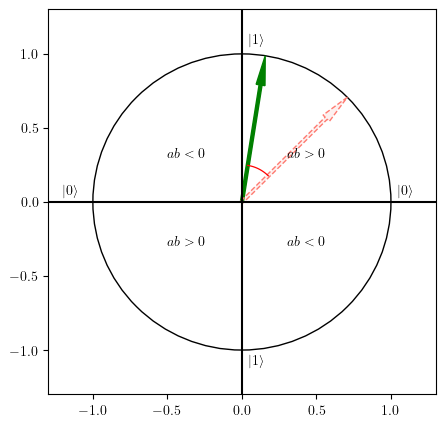

In [14]:
angle = 0.2*np.pi
a_temp = a*np.cos(angle) - b*np.sin(angle)
b_temp = a*np.sin(angle) + b*np.cos(angle)
a_previous = a
b_previous = b
a = a_temp
b = b_temp

theta_initial = np.arccos(a_previous)
theta_new = np.arccos(a)
x_arc = np.cos(np.linspace(np.minimum(theta_initial, theta_new), np.maximum(theta_initial, theta_new), 20))*0.25
y_arc = np.sin(np.linspace(np.minimum(theta_initial, theta_new), np.maximum(theta_initial, theta_new), 20))*0.25

print("0: " + str(abs(a)**2))
print("1: " + str(abs(b)**2))
print(f"sum = {abs(a)**2 + abs(b)**2}")

circle_1 = plt.Circle((0, 0), 1, fill=False)
arrow_1 = plt.Arrow(0, 0, a, b, width=0.1, color="green")
arrow_2 = plt.Arrow(0, 0, a_previous, b_previous, width=0.1, 
                    edgecolor=(1, 122/255, 112/255, 1), linestyle="--", 
                    facecolor=(247/255, 183/255, 178/255, 0.2)) 
xaxis = plt.Line2D((-1.3, 1.3), (0, 0), c="black")
yaxis = plt.Line2D((0, 0), (-1.3, 1.3), c="black")
fig, ax = plt.subplots(figsize=(5, 5))
ax.set_ylim(-1.3, 1.3)
ax.set_xlim(-1.3, 1.3)
ax.add_patch(circle_1)
ax.add_line(xaxis)
ax.add_line(yaxis)
ax.add_patch(arrow_1)
ax.add_patch(arrow_2)
plt.text(0.05, 1.07, r"$|1\rangle$")
plt.text(0.05, -1.1, r"$|1\rangle$")
plt.text(-1.2, 0.05, r"$|0\rangle$")
plt.text(1.05, 0.05, r"$|0\rangle$")
plt.text(0.3, 0.3, r"$ab > 0$")
plt.text(-0.5, -0.3, r"$ab > 0$")
plt.text(-0.5, 0.3, r"$ab < 0$")
plt.text(0.3, -0.3, r"$ab < 0$")
plt.plot(x_arc, y_arc, color="r", linewidth=0.9)
plt.show()

The local search schedule

In [23]:
T = 10
C_tot = 150
c_init = 0

lb_init = 0
ub_init = 0.1

lb = lambda c: (c**2)/(C_tot**2)
ub = lambda c: np.log(c)/np.log(C_tot)

group_list = [[] for i in range(T-1)]
d_list = []
c_list = np.arange(c_init, C_tot)
for c in range(c_init, C_tot):
    c = np.array([c])
    cur_lb = lb(c)
    cur_ub = ub(c)
    cur_ub[np.where(cur_ub < ub_init)[0]] = ub_init
    cur_lb[np.where(cur_lb < lb_init)[0]] = lb_init
    d = (cur_ub - cur_lb)/(T-1)
    d_list.append(d)
    for g in range(T-1):
        group_list[g].append(cur_ub - (g+1)*d)


C:\Users\b-mor\AppData\Local\Temp\ipykernel_23408\244091535.py:9: RuntimeWarning: divide by zero encountered in log
  ub = lambda c: np.log(c)/np.log(C_tot)


Text(0.5, 0, 'generation')

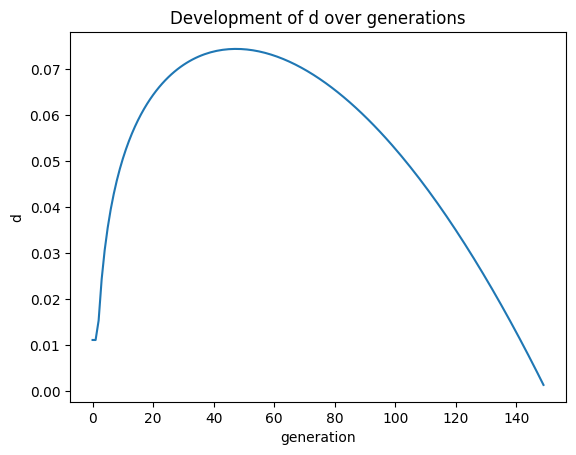

In [24]:
plt.plot(c_list, np.array(d_list))
plt.title("Development of d over generations")
plt.ylabel("d")
plt.xlabel("generation")

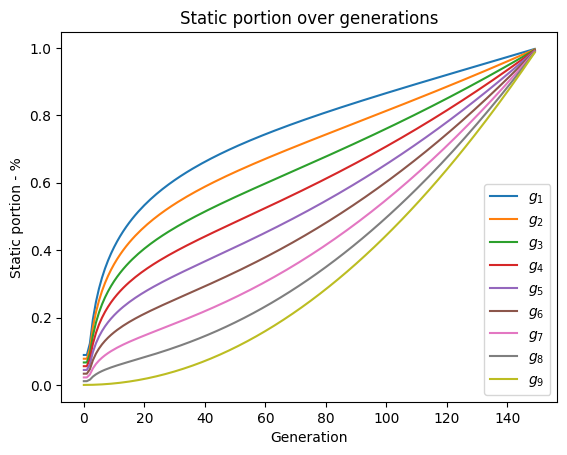

In [25]:
for i in range(T-1):
    plt.plot(np.arange(c_init, C_tot), np.asarray(group_list)[i, :, :], label="$g_{" + str(i+1) + "}$")

plt.title("Static portion over generations")
plt.ylabel("Static portion - %")
plt.xlabel("Generation")
plt.legend()
plt.show()

Plotting the funcitos used to create the schedule.

In [ ]:
x = np.arange(0, C_tot) #np.linspace(0, C_tot, 1000)
y = np.log(x)/np.log(C_tot)
y[np.where(y < ub_init)[0]] = ub_init
plt.scatter(x, y)

NameError: name 'C_tot' is not defined

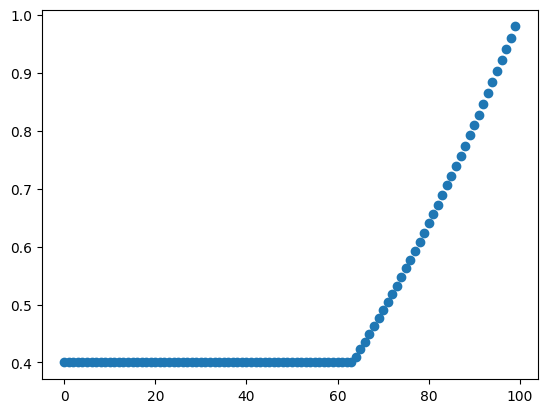

In [10]:
x = np.arange(0, C_tot)
y = (x**2)/(C_tot**2)
y[np.where(y < lb_init)[0]] = lb_init
plt.scatter(x, y)

In [5]:
T = 10
C_tot = 150
c_init = 0

lb_init = 0
ub_init = 0.1

C:\Users\b-mor\AppData\Local\Temp\ipykernel_23408\2471016448.py:2: RuntimeWarning: divide by zero encountered in log
  y = np.log(x%50)/np.log(50*0.9)


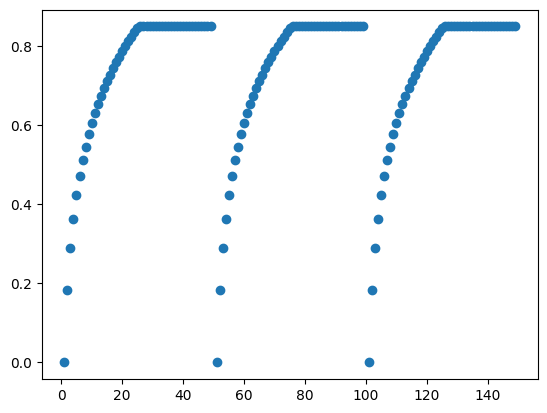

In [28]:
x = np.arange(0, C_tot) #np.linspace(0, C_tot, 1000)
y = np.log(x%50)/np.log(50*0.9)
y[np.where(y > 0.85)[0]] = 0.85
plt.scatter(x, y)

In [ ]:
lb = lambda c: (c**2)/(C_tot**2)
ub = lambda c: np.log(c)/np.log(C_tot)

group_list = [[] for i in range(T-1)]
d_list = []
c_list = np.arange(c_init, C_tot)
for c in range(c_init, C_tot):
    c = np.array([c])
    cur_lb = lb(c)
    cur_ub = ub(c)
    cur_ub[np.where(cur_ub < ub_init)[0]] = ub_init
    cur_lb[np.where(cur_lb < lb_init)[0]] = lb_init
    d = (cur_ub - cur_lb)/(T-1)
    d_list.append(d)
    for g in range(T-1):
        group_list[g].append(cur_ub - (g+1)*d)